In [2]:
from dotenv import load_dotenv
load_dotenv()

import numpy as np
from pixell import enmap, enplot, reproject
import glob
import matplotlib.pyplot as plt
import emcee, corner
from astropy.io import fits
import sys
from astropy import units as u, constants as const
sys.path.insert(0, '../src')
#sys.path.insert(0, "/home/gill/apps/szpack/python")
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
import yaml
import itertools
from pixell import enmap

# Compton y calculation
from astropy.constants import k_B, m_p, c, sigma_T, m_e
from astropy import units as u

from astropy.coordinates import SkyCoord
import astropy.units as u

import utils as ut

# latex font
plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif', size=18)

In [3]:
def calc_y_and_err(tau, tau_err, Te, Te_err):
    Te = Te * u.keV
    Te_err = Te_err * u.keV
    Te_K = (Te / k_B).to(u.K)    
    Te_err_K = (Te_err / k_B).to(u.K)

    y = tau * k_B * Te_K / (m_e * c**2).to(u.J)
    yerr = y * np.sqrt((tau_err / tau)**2 + (Te_err_K / Te_K)**2)

    return y.value, yerr.value

def get_y_vector(samples, idx_tau, idx_Te):
    Te = samples[:, idx_Te] * u.keV
    tau = samples[:, idx_tau]
    Te_K = (Te / k_B).to(u.K)
    y = tau * k_B * Te_K / (m_e * c**2).to(u.J)
    return y.value

def calc_mean_and_std(samples, idx):
    data = samples[:, idx]

    mcmc_run = np.percentile(data, [16, 50, 84])
    err = .5 * (mcmc_run[2] - mcmc_run[0])
    
    # Calculate bin width using Freedman-Diaconis rule
    n = len(data)
    iqr = np.percentile(data, 75) - np.percentile(data, 25)
    bin_width = 2 * iqr * n**(-1/3)

    # Calculate number of bins using bin width
    num_bins = int((np.max(data) - np.min(data)) / bin_width)

    # Create histogram
    hist, bin_edges = np.histogram(data, bins=num_bins, density=True)

    # Find bin with maximum value (estimate of mode)
    mode_bin = np.argmax(hist)
    mode_value = 0.5 * (bin_edges[mode_bin] + bin_edges[mode_bin + 1])

    mean = mode_value
    std = err
    return mean, std

In [4]:
# indices for the chain parameters
param_indices = {
    'ra_a401': 0,
    'dec_a401': 1,
    'beta_a401': 2,
    'rc_a401': 3,
    'R_a401': 4,
    'theta_a401': 5,
    'tau_a401': 6,
    'Te_a401': 7,
    'AD_a401': 8,

    'ra_a399': 9,
    'dec_a399': 10,
    'beta_a399': 11,
    'rc_a399': 12,
    'R_a399': 13,
    'theta_a399': 14,
    'tau_a399': 15,
    'Te_a399': 16,
    'AD_a399': 17,

    'fil_ra': 18,
    'fil_dec': 19,
    'fil_l0': 20,
    'fil_w0': 21,
    'tau_fil': 22,
    'Te_fil': 23,
    'fil_AD': 24,
    'fil_vavg': 25
}

case10 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case10/chain.h5"
case27 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case27/chain.h5"
case28 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case28/chain.h5"
case31 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case31/chain.h5"
case32 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case32/chain.h5"
case33 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case33/chain.h5"

In [6]:
burnin = 30000
thin = 1
samples_case10 = emcee.backends.HDFBackend(case10).get_chain(discard=burnin, flat=True, thin=thin)
samples_case27 = emcee.backends.HDFBackend(case27).get_chain(discard=burnin, flat=True, thin=thin)
samples_case28 = emcee.backends.HDFBackend(case28).get_chain(discard=burnin, flat=True, thin=thin)
samples_case31 = emcee.backends.HDFBackend(case31).get_chain(discard=burnin, flat=True, thin=thin)
samples_case32 = emcee.backends.HDFBackend(case32).get_chain(discard=burnin, flat=True, thin=thin)
samples_case33 = emcee.backends.HDFBackend(case33).get_chain(discard=burnin, flat=True, thin=thin)

print("Number of samples for case 10: {:.0f}".format(samples_case10.shape[0] / emcee.backends.HDFBackend(case10).shape[0]))
print("Number of iterations for case 27: {:.0f}".format(samples_case27.shape[0] / emcee.backends.HDFBackend(case27).shape[0]))
print("Number of iterations for case 28: {:.0f}".format(samples_case28.shape[0] / emcee.backends.HDFBackend(case28).shape[0]))
print("Number of iterations for case 31: {:.0f}".format(samples_case31.shape[0] / emcee.backends.HDFBackend(case31).shape[0]))
print("Number of iterations for case 32: {:.0f}".format(samples_case32.shape[0] / emcee.backends.HDFBackend(case32).shape[0]))
print("Number of iterations for case 33: {:.0f}".format(samples_case33.shape[0] / emcee.backends.HDFBackend(case33).shape[0]))

Number of samples for case 10: 79374
Number of iterations for case 27: 47390
Number of iterations for case 28: 33895
Number of iterations for case 31: 33677
Number of iterations for case 32: 33223
Number of iterations for case 33: 33399


In [7]:
cases = [
    (samples_case10, "case10"),
    (samples_case27, "case27"),
    (samples_case28, "case28"),
    (samples_case31, "case31"),
    (samples_case32, "case32"),
    (samples_case33, "case33")
]

case_labels = ["Temperature: X-ray", 
               r"5\% higher than X-ray", 
               r"10\% higher than X-ray", 
               r"15\% higher than X-ray", 
               r"20\% higher than X-ray", 
               r"25\% higher than X-ray",
]

In [8]:
# Compton y fits
# --- A401 ---
# Compton-y fit
compton_y_fits = {
    "ra_a401_mean": 44.751,
    "ra_a401_std": 0.002,
    "dec_a401_mean": 13.572,
    "dec_a401_std": 0.002,
    "beta_a401_mean": 0.82,
    "beta_a401_std": 0.05,
    "rc_a401_mean": 2.6,
    "rc_a401_std": 0.35,
    "R_a401_mean": 0.82,
    "R_a401_std": 0.055,
    "theta_a401_mean": 123,
    "theta_a401_std": 8.5,
    "y_a401_mean": 1.260e-04,
    "y_a401_std": 6.00e-06,
    
    "ra_a399_mean": 44.473,
    "ra_a399_std": 0.004,
    "dec_a399_mean": 13.03,
    "dec_a399_std": 0.003,
    "beta_a399_mean": 0.81,
    "beta_a399_std": 0.095,
    "rc_a399_mean": 3.0,
    "rc_a399_std": 0.65,
    "R_a399_mean": 0.93,
    "R_a399_std": 0.06,
    "theta_a399_mean": 133,
    "theta_a399_std": 26.5,
    "y_a399_mean": 8.100e-05,
    "y_a399_std": 6.00e-06,
    
    "fil_ra_mean": 44.68,
    "fil_ra_std": 0.02,
    "fil_dec_mean": 13.37,
    "fil_dec_std": 0.025,
    "fil_l0_mean": 12.3,
    "fil_l0_std": 1.55,
    "fil_w0_mean": 10.8,
    "fil_w0_std": 1.05,
    "y_fil_mean": 1.100e-05,
    "y_fil_std": 1.750e-06,
}

In [11]:
def result_comparer(samples, compton_y_fits, param_indices, cf_path):
    # create a dictionary of the sample results
    # create the labels first for the dictionary
    print("Working on config file path:", cf_path)
    ## Take care of RA and DEC values 
    cf = ut.get_config_file(f'{cf_path}')

    region = ut.get_region(cf['region_center_ra'], 
                           cf['region_center_dec'], 
                           cf['region_width'])

    dire_data = "/home/gill/research/ACT/bridge/data_paper/data/data/act_no_reproj"
    data_ref = enmap.read_map(f"{dire_data}/act_cut_dr6v2_pa5_f098_4way_coadd_map_srcfree.fits", 
                              box=region)
    
    a401_ra_pix = samples[:, param_indices['ra_a401']]
    a401_dec_pix = samples[:, param_indices['dec_a401']]

    a399_ra_pix = samples[:, param_indices['ra_a399']]
    a399_dec_pix = samples[:, param_indices['dec_a399']]

    fil_ra_pix = samples[:, param_indices['fil_ra']]
    fil_dec_pix = samples[:, param_indices['fil_dec']]

    ra_a401, dec_a401 = data_ref.wcs.celestial.wcs_pix2world(a401_ra_pix, a401_dec_pix, 0)
    samples[:, param_indices['ra_a401']] = ra_a401
    samples[:, param_indices['dec_a401']] = dec_a401

    ra_a399, dec_a399 = data_ref.wcs.celestial.wcs_pix2world(a399_ra_pix, a399_dec_pix, 0)
    samples[:, param_indices['ra_a399']] = ra_a399
    samples[:, param_indices['dec_a399']] = dec_a399

    fil_ra, fil_dec = data_ref.wcs.celestial.wcs_pix2world(fil_ra_pix, fil_dec_pix, 0)
    samples[:, param_indices['fil_ra']] = fil_ra
    samples[:, param_indices['fil_dec']] = fil_dec

    samples[:, param_indices["fil_l0"]] *= 0.5
    samples[:, param_indices["fil_w0"]] *= 0.5

    samples[:, param_indices["R_a401"]] = 1 / samples[:, param_indices["R_a401"]]
    samples[:, param_indices["R_a399"]] = 1 / samples[:, param_indices["R_a399"]]
    
    # create a dictionary to hold the results
    labels = {
        "ra_a401_mean": 0,
        "ra_a401_std": 0,

        "dec_a401_mean": 0,
        "dec_a401_std": 0,

        "beta_a401_mean": 0,
        "beta_a401_std": 0,

        "rc_a401_mean": 0,
        "rc_a401_std": 0,

        "R_a401_mean": 0,
        "R_a401_std": 0,

        "theta_a401_mean": 0,
        "theta_a401_std": 0,

        "tau_a401_mean": 0,
        "tau_a401_std": 0,

        "Te_a401_mean": 0,
        "Te_a401_std": 0,

        "AD_a401_mean": 0,
        "AD_a401_std": 0,

        "ra_a399_mean": 0,
        "ra_a399_std": 0,

        "dec_a399_mean": 0,
        "dec_a399_std": 0,

        "beta_a399_mean": 0,
        "beta_a399_std": 0,

        "rc_a399_mean": 0,
        "rc_a399_std": 0,

        "R_a399_mean": 0,
        "R_a399_std": 0,

        "theta_a399_mean": 0,
        "theta_a399_std": 0,

        "tau_a399_mean": 0,
        "tau_a399_std": 0,

        "Te_a399_mean": 0,
        "Te_a399_std": 0,

        "AD_a399_mean": 0,
        "AD_a399_std": 0,

        "fil_ra_mean": 0,
        "fil_ra_std": 0,

        "fil_dec_mean": 0,
        "fil_dec_std": 0,

        "fil_l0_mean": 0,
        "fil_l0_std": 0,

        "fil_w0_mean": 0,
        "fil_w0_std": 0,

        "tau_fil_mean": 0,
        "tau_fil_std": 0,

        "Te_fil_mean": 0,
        "Te_fil_std": 0,

        "fil_AD_mean": 0,
        "fil_AD_std": 0,

        "fil_vavg_mean": 0,
        "fil_vavg_std": 0,

        "y_a401_mean": 0,
        "y_a401_std": 0,
        
        "y_a399_mean": 0,
        "y_a399_std": 0,

        "y_fil_mean": 0,
        "y_fil_std": 0,
    }

    # calculate the mean and std for each param in labels
    for key in labels.keys():
        if "std" in key:
            continue
        
        if "y_" in key:
            object_name = key.split('_')[1]
            Te = labels[f'Te_{object_name}_mean']
            Te_err = labels[f'Te_{object_name}_std']
            tau = labels[f'tau_{object_name}_mean']
            tau_err = labels[f'tau_{object_name}_std']
            y, yerr = calc_y_and_err(tau, tau_err, Te, Te_err)

            labels[key] = y
            labels[key.replace("mean", "std")] = yerr
        else:
            idx = param_indices[key.split('_')[0] + '_' + key.split('_')[1]]
            mean, std = calc_mean_and_std(samples, idx)
            labels[key] = mean
            labels[key.replace("mean", "std")] = std

    print("Results:")
    for key, value in labels.items():
        print(f"{key}: {value:.7f}")

    # for each parameter that is common between labels and compton_y_fits, compare the values 
    # and print the difference in standard deviations
    print("\nComparison with Compton y fits:")
    
    for key in labels.keys():
        if "mean" not in key:
            continue
        if key in compton_y_fits:
            diff = (labels[key] - compton_y_fits[key]) / (np.sqrt(labels[key.replace("mean", "std")]**2 + compton_y_fits[key.replace("mean", "std")]**2))
            print(f"{key}: {labels[key]:.7f} vs {compton_y_fits[key]:.7f} | Diff: {diff:.2f} σ")
        else:
            print(f"{key} not found in Compton y fits")

    a401_y_vector = get_y_vector(samples, param_indices['tau_a401'], param_indices['Te_a401'])
    a399_y_vector = get_y_vector(samples, param_indices['tau_a399'], param_indices['Te_a399'])
    fil_y_vector = get_y_vector(samples, param_indices['tau_fil'], param_indices['Te_fil'])

    return a401_y_vector, a399_y_vector, fil_y_vector

    # # Plot the y distributions
    # plt.figure(figsize=(15, 8))
    # plt.hist(a401_y_vector, bins=50, alpha=0.5, label='A401 y', density=True, histtype='stepfilled')
    # plt.hist(a399_y_vector, bins=50, alpha=0.5, label='A399 y', density=True, histtype='stepfilled')
    # plt.hist(fil_y_vector, bins=50, alpha=0.5, label='Filament y', density=True, histtype='stepfilled')

    # # plot the compton y- y paramter assuming a normal distribution (np.normal(loc=mean, scale=std))
    # plt.hist(np.random.normal(compton_y_fits['y_a401_mean'], compton_y_fits['y_a401_std'], 10000), 
    #          histtype='stepfilled',
    #          bins=50, alpha=0.5, label='A401 y (Compton fit)', density=True)
    # plt.hist(np.random.normal(compton_y_fits['y_a399_mean'], compton_y_fits['y_a399_std'], 10000),
    #             histtype='stepfilled',
    #          bins=50, alpha=0.5, label='A399 y (Compton fit)', density=True)
    # plt.hist(np.random.normal(compton_y_fits['y_fil_mean'], compton_y_fits['y_fil_std'], 10000),
    #             histtype='stepfilled',
    #          bins=50, alpha=0.5, label='Filament y (Compton fit)', density=True)
    
    # plt.xlabel('Compton y')
    # plt.ylabel('Density')
    # plt.title('Compton y Distributions')
    # plt.legend()
    # plt.show()

In [10]:
configs = [
    "/home/gill/research/ACT/multi-freq-bridge/configs/case10_ajay.yaml", 
    "/home/gill/research/ACT/multi-freq-bridge/configs/case27_ajay.yaml",
    "/home/gill/research/ACT/multi-freq-bridge/configs/case28_ajay.yaml",
    "/home/gill/research/ACT/multi-freq-bridge/configs/case31_ajay.yaml",
    "/home/gill/research/ACT/multi-freq-bridge/configs/case32_ajay.yaml",
    "/home/gill/research/ACT/multi-freq-bridge/configs/case33_ajay.yaml",
]

a401_y_vector_case10, a399_y_vector_case10, fil_y_vector_case10 = result_comparer(samples_case10, compton_y_fits, param_indices, configs[0])
a401_y_vector_case27, a399_y_vector_case27, fil_y_vector_case27 = result_comparer(samples_case27, compton_y_fits, param_indices, configs[1])
a401_y_vector_case28, a399_y_vector_case28, fil_y_vector_case28 = result_comparer(samples_case28, compton_y_fits, param_indices, configs[2])
a401_y_vector_case31, a399_y_vector_case31, fil_y_vector_case31 = result_comparer(samples_case31, compton_y_fits, param_indices, configs[3])
a401_y_vector_case32, a399_y_vector_case32, fil_y_vector_case32 = result_comparer(samples_case32, compton_y_fits, param_indices, configs[4])
a401_y_vector_case33, a399_y_vector_case33, fil_y_vector_case33 = result_comparer(samples_case33, compton_y_fits, param_indices, configs[5])

Results:
ra_a401_mean: 44.7410954
ra_a401_std: 0.0016877
dec_a401_mean: 13.5795365
dec_a401_std: 0.0023340
beta_a401_mean: 1.2332130
beta_a401_std: 0.0917503
rc_a401_mean: 4.4739361
rc_a401_std: 0.4950341
R_a401_mean: 0.7843064
R_a401_std: 0.0574513
theta_a401_mean: 107.4822854
theta_a401_std: 6.6547084
tau_a401_mean: 0.0074791
tau_a401_std: 0.0004800
Te_a401_mean: 8.4557781
Te_a401_std: 0.2473526
AD_a401_mean: 1157.9372724
AD_a401_std: 167358.6031768
ra_a399_mean: 44.4655946
ra_a399_std: 0.0031331
dec_a399_mean: 13.0403484
dec_a399_std: 0.0035741
beta_a399_mean: 0.9923633
beta_a399_std: 0.0658259
rc_a399_mean: 4.2297735
rc_a399_std: 0.5389322
R_a399_mean: 0.8588137
R_a399_std: 0.0827742
theta_a399_mean: 107.9564838
theta_a399_std: 20.4559526
tau_a399_mean: 0.0062699
tau_a399_std: 0.0004397
Te_a399_mean: 7.2253571
Te_a399_std: 0.1887496
AD_a399_mean: 8272.9036865
AD_a399_std: 171039.1790670
fil_ra_mean: 44.6735556
fil_ra_std: 0.0233262
fil_dec_mean: 13.3484833
fil_dec_std: 0.0387094
fi

In [ ]:
a401_y_vector_case10, a399_y_vector_case10, fil_y_vector_case10 = result_comparer(samples_case10, compton_y_fits, param_indices, configs[0])


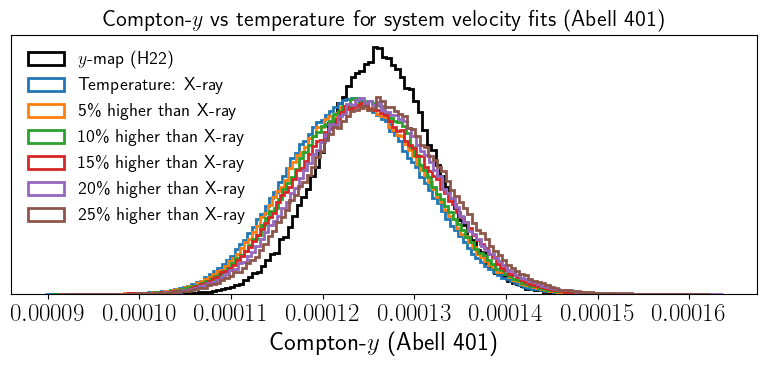

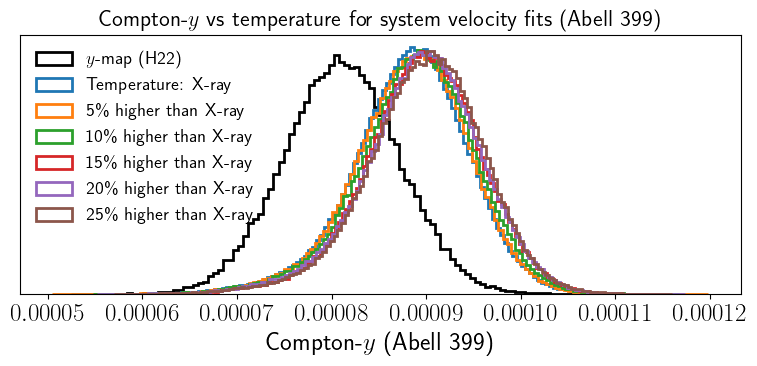

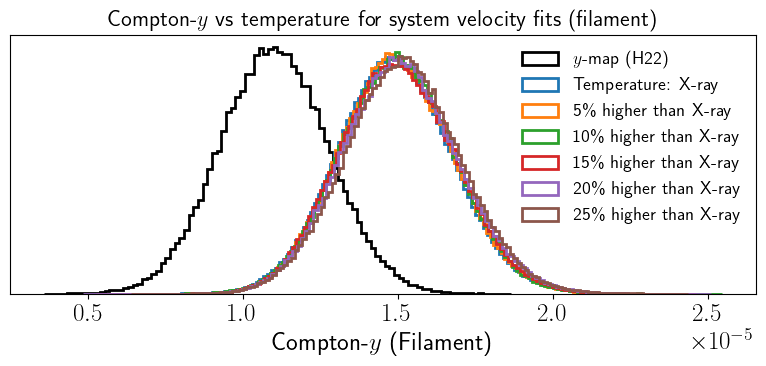

In [12]:
# plot the y distributions for each case - separate figures
# A401 Compton-y distributions
plt.figure(figsize=(8, 4))
plt.hist(np.random.normal(compton_y_fits['y_a401_mean'], compton_y_fits['y_a401_std'], 100000), 
         histtype='step', color='black', linestyle='-',
         bins=100, alpha=1, label='$y$-map (H22)', density=True, lw=2)
plt.hist(a401_y_vector_case10, bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(a401_y_vector_case27, bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(a401_y_vector_case28, bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(a401_y_vector_case31, bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(a401_y_vector_case32, bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(a401_y_vector_case33, bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Compton-$y$ (Abell 401)')
plt.legend(fontsize=13, frameon=False, loc="upper left")
plt.gca().set_yticks([])
plt.title("Compton-$y$ vs temperature for system velocity fits (Abell 401)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/y_Te_system_vc_a401.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

# A399 Compton-y distributions
plt.figure(figsize=(8, 4))
plt.hist(np.random.normal(compton_y_fits['y_a399_mean'], compton_y_fits['y_a399_std'], 100000), 
         histtype='step', 
         bins=100, alpha=1, label='$y$-map (H22)', density=True, lw=2, color='black', linestyle='-')
plt.hist(a399_y_vector_case10, bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(a399_y_vector_case27, bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(a399_y_vector_case28, bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(a399_y_vector_case31, bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(a399_y_vector_case32, bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(a399_y_vector_case33, bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)
plt.title("Compton-$y$ vs temperature for system velocity fits (Abell 399)", fontsize=16)

plt.xlabel('Compton-$y$ (Abell 399)')
plt.legend(fontsize=13, frameon=False, loc="upper left")
plt.gca().set_yticks([])
plt.tight_layout()
# plt.xlim(0.00006, 0.00012)
plt.savefig("../plots/y_Te_system_vc_a399.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

# Filament Compton-y distributions
plt.figure(figsize=(8, 4))
plt.hist(np.random.normal(compton_y_fits['y_fil_mean'], compton_y_fits['y_fil_std'], 100000), 
         histtype='step', 
         bins=100, alpha=1, label='$y$-map (H22)', density=True, lw=2, color='black', linestyle='-')

plt.hist(fil_y_vector_case10, bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(fil_y_vector_case27, bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(fil_y_vector_case28, bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(fil_y_vector_case31, bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(fil_y_vector_case32, bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(fil_y_vector_case33, bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)
plt.title("Compton-$y$ vs temperature for system velocity fits (filament)", fontsize=16)

plt.xlabel('Compton-$y$ (Filament)')
plt.legend(fontsize=13, frameon=False)
plt.gca().set_yticks([])
plt.tight_layout()
plt.savefig("../plots/y_Te_system_vc_fil.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()


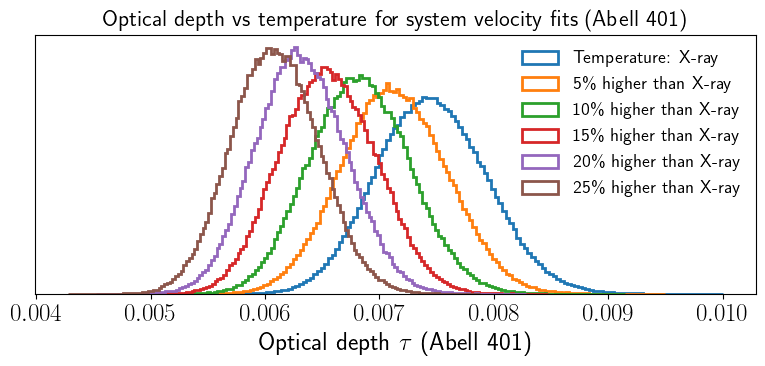

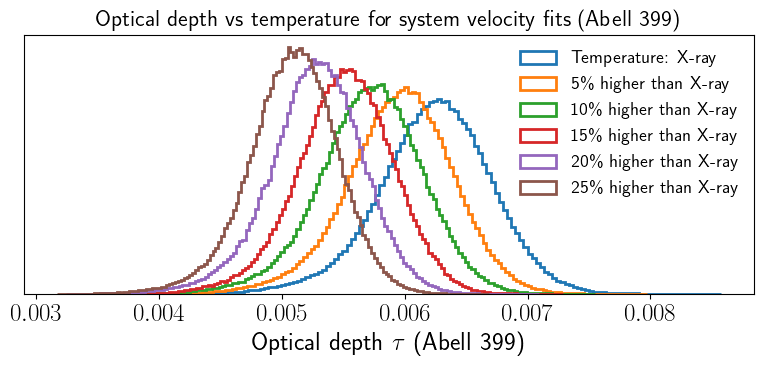

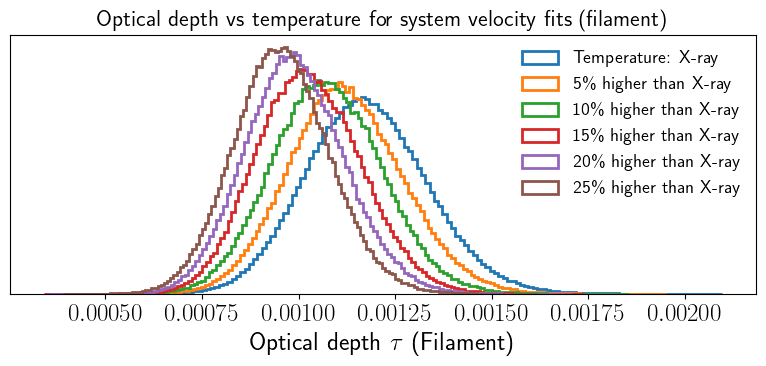

In [13]:
# Plot tau distributions for each case - separate figures
# A401 Tau distributions
plt.figure(figsize=(8, 4))
plt.hist(samples_case10[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case27[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case28[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case31[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case32[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case33[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Optical depth $\\tau$ (Abell 401)')
plt.legend(fontsize=13, frameon=False, loc="upper right")
plt.gca().set_yticks([])
plt.title("Optical depth vs temperature for system velocity fits (Abell 401)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/tau_Te_system_vc_a401.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

# A399 Tau distributions
plt.figure(figsize=(8, 4))
plt.hist(samples_case10[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case27[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case28[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case31[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case32[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case33[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Optical depth $\\tau$ (Abell 399)')
plt.legend(fontsize=13, frameon=False, loc="upper right")
plt.gca().set_yticks([])
plt.title("Optical depth vs temperature for system velocity fits (Abell 399)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/tau_Te_system_vc_a399.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

# Filament Tau distributions
plt.figure(figsize=(8, 4))
plt.hist(samples_case10[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case27[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case28[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case31[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case32[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case33[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Optical depth $\\tau$ (Filament)')
plt.legend(fontsize=13, frameon=False)
plt.gca().set_yticks([])
plt.title("Optical depth vs temperature for system velocity fits (filament)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/tau_Te_system_vc_fil.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

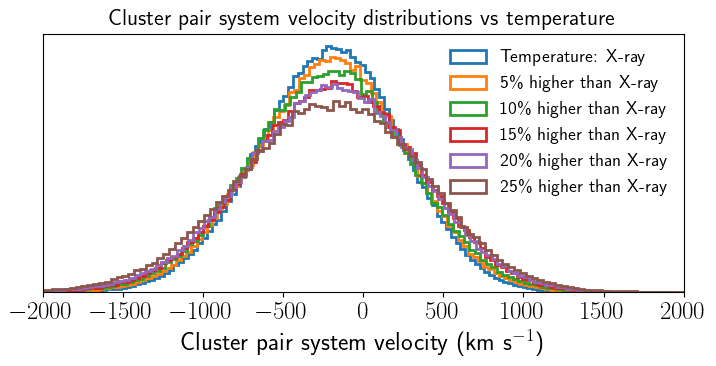

In [14]:
# plot velocity distributions for each case on the same figure
plt.figure(figsize=(7, 4))
plt.hist(samples_case10[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case27[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case28[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case31[:, param_indices['fil_vavg']], bins=150, alpha= 1, label=case_labels[3], density=True, histtype='step', lw=2)   
plt.hist(samples_case32[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case33[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)
plt.xlabel('Cluster pair system velocity (km s$^{-1}$)')
plt.legend(fontsize=13, frameon=False)
plt.gca().set_yticks([])
plt.title("Cluster pair system velocity distributions vs temperature", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/fil_vavg_system_vc_vs_Te.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.xlim(-2000, 2000)
plt.show()

In [ ]:
# velocity compare
# Plot tau distributions for each case - separate figures
# A401 Tau distributions
plt.figure(figsize=(8, 4))
plt.hist(samples_case23[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case34[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case35[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case36[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case37[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case38[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Optical depth $\\tau$ (Abell 401)')
plt.legend(fontsize=13, frameon=False, loc="upper right")
plt.gca().set_yticks([])
plt.title("Optical depth vs temperature for individual velocity fits (Abell 401)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/tau_Te_ind_vc_a401.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

# A399 Tau distributions
plt.figure(figsize=(8, 4))
plt.hist(samples_case23[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case34[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case35[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case36[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case37[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case38[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Optical depth $\\tau$ (Abell 399)')
plt.legend(fontsize=13, frameon=False, loc="upper right")
plt.gca().set_yticks([])
plt.title("Optical depth vs temperature for individual velocity fits (Abell 399)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/tau_Te_ind_vc_a399.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

# Filament Tau distributions
plt.figure(figsize=(8, 4))
plt.hist(samples_case23[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case34[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case35[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case36[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case37[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case38[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Optical depth $\\tau$ (Filament)')
plt.legend(fontsize=13, frameon=False)
plt.gca().set_yticks([])
plt.title("Optical depth vs temperature for individual velocity fits (filament)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/tau_Te_ind_vc_fil.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

In [ ]:
# Plot velocity distributions for each case - separate figures
# A401 velocity distributions
plt.figure(figsize=(8, 4))
plt.hist(samples_case23[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case34[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case35[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case36[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case37[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case38[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Radial velocity (km/s) (Abell 401)')
plt.legend(fontsize=13, frameon=False, loc="upper right")
plt.gca().set_yticks([])
plt.title("Radial velocity vs temperature for individual velocity fits (Abell 401)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/vr_Te_ind_vc_a401.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

# A399 velocity distributions
plt.figure(figsize=(8, 4))
plt.hist(samples_case23[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case34[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case35[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case36[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case37[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case38[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Radial velocity (km/s) (Abell 399)')
plt.legend(fontsize=13, frameon=False, loc="upper right")
plt.gca().set_yticks([])
plt.title("Radial velocity vs temperature for individual velocity fits (Abell 399)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/vr_Te_ind_vc_a399.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

# Filament velocity distributions
plt.figure(figsize=(8, 4))
plt.hist(samples_case23[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case34[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case35[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case36[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case37[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case38[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Average velocity (km/s) (Filament)')
plt.legend(fontsize=13, frameon=False)
plt.gca().set_yticks([])
plt.title("Average velocity vs temperature for individual velocity fits (filament)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/vavg_Te_ind_vc_fil.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()


In [ ]:
# Plot velocity distributions for each case - separate figures
# A401 velocity distributions
plt.figure(figsize=(7, 4))
plt.hist(samples_case23[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case34[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case35[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case36[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case37[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case38[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Velocity (km s$^{-1}$) (Abell 401)')
plt.legend(fontsize=14, frameon=False, loc="upper left")
plt.gca().set_yticks([])
plt.title("Velocity vs temperature for individual velocity fits (Abell 401)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/vr_Te_ind_vc_a401.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

# A399 velocity distributions
plt.figure(figsize=(7, 4))
plt.hist(samples_case23[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case34[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case35[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case36[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case37[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case38[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Velocity (km s$^{-1}$) (Abell 399)')
plt.legend(fontsize=14, frameon=False, loc="upper left")
plt.gca().set_yticks([])
plt.title("Velocity vs temperature for individual velocity fits (Abell 399)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/vr_Te_ind_vc_a399.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

# Filament velocity distributions
plt.figure(figsize=(7, 4))
plt.hist(samples_case23[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case34[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case35[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case36[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case37[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case38[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Velocity (km s$^{-1}$) (Filament)')
plt.legend(fontsize=14, frameon=False)
plt.gca().set_yticks([])
plt.title("Velocity vs temperature for individual velocity fits (filament)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/vavg_Te_ind_vc_fil.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()


In [ ]:
# Te distributions for each case
plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
plt.hist(samples_case24[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
plt.hist(samples_case25[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
plt.hist(samples_case26[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(samples_case27[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(samples_case32[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Temperature (keV)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
#plt.savefig("temperature_a401_distributions.png", bbox_inches='tight')
plt.show()
# Te distributions for A399
plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
plt.hist(samples_case24[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
plt.hist(samples_case25[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
plt.hist(samples_case26[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)     
plt.hist(samples_case27[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(samples_case32[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Temperature (keV)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
#plt.savefig("temperature_a399_distributions.png", bbox_inches='tight')
plt.show()
# Te distributions for Filament
plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)  
plt.hist(samples_case24[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
plt.hist(samples_case25[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
plt.hist(samples_case26[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(samples_case27[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(samples_case32[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Temperature (keV)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
#plt.savefig("temperature_filament_distributions.png", bbox_inches='tight')
plt.show()

In [ ]:
# tau histograms for a401   
plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
#plt.hist(samples_case24[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
#plt.hist(samples_case25[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
# plt.hist(samples_case26[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(samples_case27[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)    
plt.hist(samples_case32[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Optical depth (A401)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
plt.xlim(0.004, 0.01)
#plt.savefig("tau_a401_distributions.png", bbox_inches='tight')
plt.show()

# tau histograms for a399
plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
#plt.hist(samples_case24[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
#plt.hist(samples_case25[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)    
# plt.hist(samples_case26[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(samples_case27[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(samples_case32[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Optical depth (A399)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
plt.xlim(0.003, 0.008)
#plt.savefig("tau_a399_distributions.png", bbox_inches='tight')
plt.show()

# tau histograms for filament
plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
#plt.hist(samples_case24[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
#plt.hist(samples_case25[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
# plt.hist(samples_case26[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(samples_case27[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(samples_case32[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Optical depth (Filament)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
plt.xlim(0.0005, 0.0017)
#plt.savefig("tau_filament_distributions.png", bbox_inches='tight')
plt.show()

In [ ]:
# plot the histograms of the temperature for each case with three subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# A401 temperatures
for i, (samples, case_name) in enumerate(cases):
    Te_a401 = samples[:, param_indices['Te_a401']]
    axes[0].hist(Te_a401, bins=50, alpha=0.7, label=f'{case_name}', density=True, histtype='step')
axes[0].set_xlabel('Temperature (keV)')
axes[0].set_ylabel('Density')
axes[0].set_title('A401 Temperature Distributions')
axes[0].legend()

# A399 temperatures
for i, (samples, case_name) in enumerate(cases):
    Te_a399 = samples[:, param_indices['Te_a399']]
    axes[1].hist(Te_a399, bins=50, alpha=0.7, label=f'{case_name}', density=True, histtype='step')
axes[1].set_xlabel('Temperature (keV)')
axes[1].set_ylabel('Density')
axes[1].set_title('A399 Temperature Distributions')
axes[1].legend()

# Filament temperatures
for i, (samples, case_name) in enumerate(cases):
    Te_fil = samples[:, param_indices['Te_fil']]
    axes[2].hist(Te_fil, bins=50, alpha=1, lw=3, label=f'{case_name}', density=True, histtype='step')
axes[2].set_xlabel('Temperature (keV)')
axes[2].set_ylabel('Density')
axes[2].set_title('Filament Temperature Distributions')
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
cf = ut.get_config_file('/home/gill/research/ACT/multi-freq-bridge/configs/case10_ajay.yaml')
region = ut.get_region(cf['region_center_ra'], 
                        cf['region_center_dec'], 
                        cf['region_width'])

dire_data = "/home/gill/research/ACT/bridge/data_paper/data/data/act_no_reproj"
data_ref = ut.imap_dim_check(enmap.read_map(f"{dire_data}/act_cut_dr6v2_pa5_f098_4way_coadd_map_srcfree.fits", 
                            box=region))

plate_scale = 0.5
r500_a401 = plate_scale * ut.get_r500(mass=cf['c1_mass'], z=cf['c1_z']) * u.arcmin
r500_a399 = plate_scale * ut.get_r500(mass=cf['c2_mass'], z=cf['c2_z']) * u.arcmin

r_core_a401 = 4.5 * u.arcmin
r_core_a399 = 4.2 * u.arcmin

ra_center_a401 = cf["c1_ra"]
dec_center_a401 = cf["c1_dec"]
ra_center_a399 = cf["c2_ra"]
dec_center_a399 = cf["c2_dec"]

In [ ]:
from pixell import colorize
colorize.mpl_register("planck")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pixell import enmap, reproject
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

# latex font
plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif', size=22)

# ---- Read and Prepare Map ----
cf = ut.get_config_file('/home/gill/research/ACT/multi-freq-bridge/configs/case10_ajay.yaml')
region = ut.get_region(cf['region_center_ra'], cf['region_center_dec'], 1.*cf['region_width'])
dire_data = "/home/gill/research/ACT/bridge/data_paper/data/data/act_no_reproj"

data_ref = ut.imap_dim_check(enmap.read_map(f"{dire_data}/act_cut_dr6v2_pa5_f098_4way_coadd_map_srcfree.fits", box=region))

# ---- Physical Parameters ----
plate_scale = 0.5  # arcmin/pixel

r500_a401 = plate_scale * ut.get_r500(mass=cf['c1_mass'], z=cf['c1_z']) * u.arcmin
r500_a399 = plate_scale * ut.get_r500(mass=cf['c2_mass'], z=cf['c2_z']) * u.arcmin

r_core_a401 = 4.5 * u.arcmin
r_core_a399 = 4.2 * u.arcmin

ra_center_a401 = cf["c1_ra"]
dec_center_a401 = cf["c1_dec"]
ra_center_a399 = cf["c2_ra"]
dec_center_a399 = cf["c2_dec"]

# ---- Setup WCS and Plot ----
wcs = data_ref.wcs
shape = data_ref.shape

fig = plt.figure(figsize=(10, 6))
ax = plt.subplot(projection=(wcs))

im = ax.imshow(data_ref, origin='lower', cmap='planck')
ax.invert_xaxis()  # Invert x-axis for RA
plt.colorbar(im, ax=ax, orientation='vertical', label='$\mu$K')

def draw_circle(ax, ra, dec, radius, **kwargs):
    """Draw a circle at (ra, dec) with radius in arcmin."""
    center = SkyCoord(ra*u.deg, dec*u.deg)
    theta = np.linspace(0, 2*np.pi, 200)
    offset = radius.to(u.deg).value
    ras = center.ra.deg + offset * np.cos(theta) / np.cos(np.deg2rad(center.dec.deg))
    decs = center.dec.deg + offset * np.sin(theta)
    ax.plot(ras, decs, transform=ax.get_transform('world'), **kwargs)

# ---- Draw circles ----
draw_circle(ax, ra_center_a401, dec_center_a401, r500_a401, color='black', lw=2, ls='-',label='$R_{500c}$ (A401)')
draw_circle(ax, ra_center_a401, dec_center_a401, r_core_a401, color='black', lw=1, ls='--', label=r'$R_{\rm core}$ (A401)')
draw_circle(ax, ra_center_a399, dec_center_a399, r500_a399, color='red', lw=2, ls='-',label='$R_{500c}$ (A399)')
draw_circle(ax, ra_center_a399, dec_center_a399, r_core_a399, color='red', lw=1, ls='--', label=r'$R_{\rm core}$ (A399)')

# ---- Plot Formatting ----
ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
ax.legend(loc='upper right', fontsize=14, facecolor='white', edgecolor='black', framealpha=1.0)

# add a text box with white background towards the bottom center of the plot saying "ACT PA5 f90"
textstr = 'ACT PA5 (90 GHz)'
props = dict(boxstyle='round', facecolor='white', alpha=1)
ax.text(0.5, 0.05, textstr, transform=ax.transAxes, fontsize=15,
        verticalalignment='center', horizontalalignment='center', bbox=props)
plt.tight_layout()
plt.savefig("../plots/map_r500_core.pdf", dpi=300, bbox_inches='tight')
plt.show()
